In [2]:
print('hello world')

hello world


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Salary Prediction using Linear Regression")
print("="*50)

# Load the dataset
data = pd.read_csv('dataset/salary_data.csv')
data = data.dropna()
print("Dataset loaded successfully!")
print(f"We have data for {len(data)} employees")
print("First 5 rows of the dataset:")
print(data.head())

Salary Prediction using Linear Regression
Dataset loaded successfully!
We have data for 373 employees
First 5 rows of the dataset:
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  



Sample employee records:
   Years of Experience    Salary
0                  5.0   90000.0
1                  3.0   65000.0
2                 15.0  150000.0
3                  7.0   60000.0
4                 20.0  200000.0
5                  2.0   55000.0
6                 12.0  120000.0
7                  4.0   80000.0
8                  1.0   45000.0
9                 10.0  110000.0

The average salary in our dataset is: Rs.100577.3


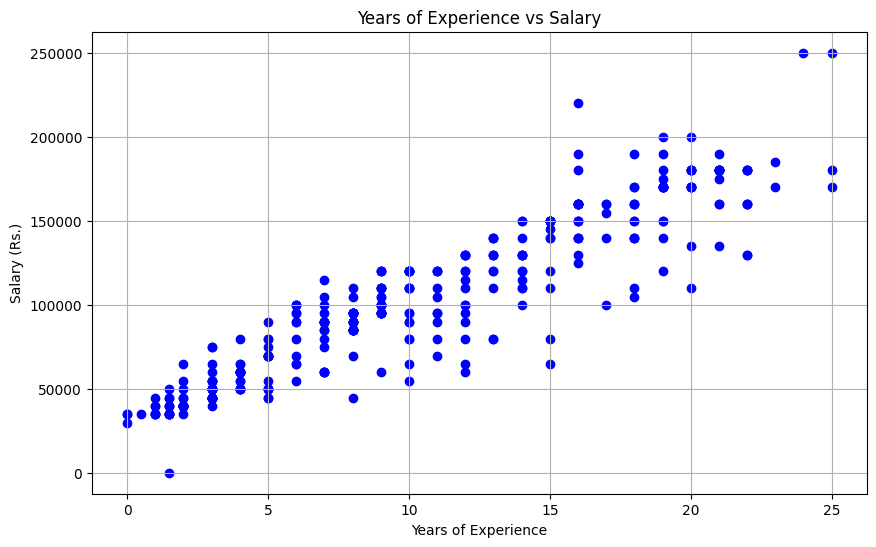

In [4]:
# Look at a few employee records
print("\nSample employee records:")
print(data[['Years of Experience', 'Salary']].head(10))

# Calculate the average salary
average_salary = data['Salary'].mean().round(1)
print(f"\nThe average salary in our dataset is: Rs.{average_salary}")

# Make a simple plot
plt.figure(figsize=(10, 6))
plt.scatter(data['Years of Experience'], data['Salary'], color='blue')
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (Rs.)')
plt.grid()

In [5]:
data[data.isnull().any(axis=1)]
data = data.dropna()
print(data.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
education_encoder = LabelEncoder()
job_encoder = LabelEncoder()

data['Gender'] = gender_encoder.fit_transform(data['Gender'])
data['Education Level'] = education_encoder.fit_transform(data['Education Level'])
data['Job Title'] = job_encoder.fit_transform(data['Job Title'])

print(data.columns.tolist())


['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']


In [7]:
# Select features and target variable
feature = data[['Years of Experience', 'Age', 'Gender', 'Education Level', 'Job Title']]
target = data['Salary']

x = feature # Feature (input)
y = target # Target variable (output)

print("Features (what we know)")
print(x.head())
print("Target variable (what we want to predict)")
print(y.head())

Features (what we know)
   Years of Experience   Age  Gender  Education Level  Job Title
0                  5.0  32.0       1                0        159
1                  3.0  28.0       0                1         17
2                 15.0  45.0       1                2        130
3                  7.0  36.0       0                0        101
4                 20.0  52.0       1                1         22
Target variable (what we want to predict)
0     90000.0
1     65000.0
2    150000.0
3     60000.0
4    200000.0
Name: Salary, dtype: float64


In [8]:
# Split the data into training (80%) and testing (20%) sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Data Split:")
print(f"Training set size: {len(x_train)}")
print(f"Testing set size: {len(x_test)}")

print(f"\nTraining features (x_train):\n{x_train.head()}")
print(f"\nTesting features (x_test):\n{x_test.head()}")
print(f"\nTraining target (y_train):\n{y_train.head()}")
print(f"\nTesting target (y_test):\n{y_test.head()}")

Data Split:
Training set size: 298
Testing set size: 75

Training features (x_train):
     Years of Experience   Age  Gender  Education Level  Job Title
193                  7.0  34.0       1                0        141
75                  10.0  37.0       1                0         96
84                   2.0  29.0       0                0         56
363                  5.0  33.0       1                0         65
16                   7.0  33.0       0                1         83

Testing features (x_test):
     Years of Experience   Age  Gender  Education Level  Job Title
329                 21.0  48.0       1                1         29
33                  10.0  39.0       0                0         84
15                  16.0  44.0       1                0         89
316                  6.0  34.0       0                1        117
57                  17.0  43.0       1                2        116

Training target (y_train):
193    95000.0
75     95000.0
84     40000.0
363    70

In [9]:
from sklearn.linear_model import LinearRegression

# Create and train the model
model = LinearRegression()
model.fit(x_train, y_train)

# Get the numbers the model learned
intercept = model.intercept_
coefficient = model.coef_[0]

print(f"Predicted Salary = {coefficient:.2f} x (Years of Experience) + {intercept:.2f}")
print("This means:")
print(f"Base Salary: {intercept:.1f}")
print(f"Each Experience: {coefficient:.2f}")
print(f"If a employee working 5 years: {5 * coefficient + intercept:.1f}")
print(f"If a employee working 10 years: {10 * coefficient + intercept:.1f}")

Predicted Salary = 2182.53 x (Years of Experience) + -64275.44
This means:
Base Salary: -64275.4
Each Experience: 2182.53
If a employee working 5 years: -53362.8
If a employee working 10 years: -42450.1


In [10]:
# Make predictions on test data
predictions = model.predict(x_test).ravel()

# create a simple table to compare
results = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": predictions.round(1),
    "Difference": abs(y_test.values - predictions).round(1)
})

print("Comparing Predictions vs Actual:")
print(results.head(10))

# Calculate average error
avg_error = results['Difference'].mean()
print(f"Average prediction error: {avg_error:.1f}")
print(f"This means on average, we're off by {avg_error:.1f}")

Comparing Predictions vs Actual:
   Actual Score  Predicted Score  Difference
0      180000.0         167633.7     12366.3
1       65000.0          93362.3     28362.3
2      125000.0         130879.6      5879.6
3       80000.0          84293.4      4293.4
4      140000.0         161044.6     21044.6
5      160000.0         159610.9       389.1
6      160000.0         157000.4      2999.6
7      120000.0         104784.3     15215.7
8       50000.0          57465.5      7465.5
9       95000.0         101175.0      6175.0
Average prediction error: 10928.9
This means on average, we're off by 10928.9


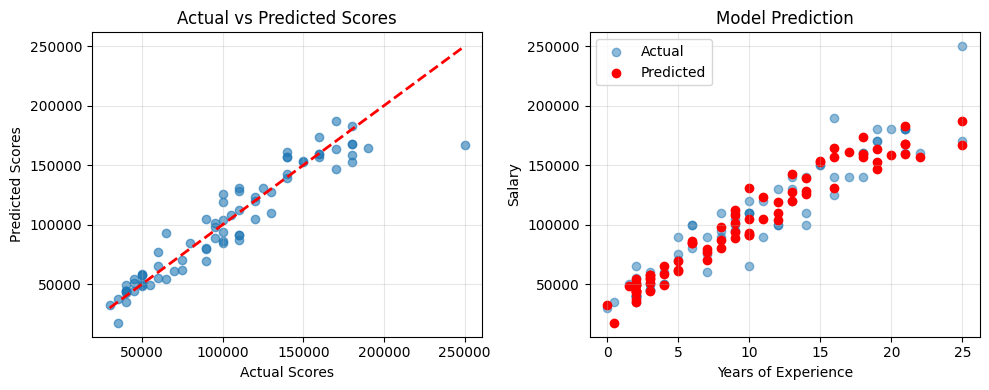

In [11]:
# Create a plot to see how well our model predicts
plt.figure(figsize=(10, 4))

# Plot1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Scores')
plt.grid(True, alpha=0.3)

# Plot2: The regression line
plt.subplot(1, 2, 2)
# use ONLY experience vs salary (simple visualization)
plt.scatter(x_test['Years of Experience'], y_test, alpha=0.5, label='Actual')
plt.scatter(x_test['Years of Experience'], predictions, color='red', label='Predicted')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Model Prediction')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Calculate simple metrics to understand model quality

from sklearn.metrics import mean_absolute_error, r2_score

# Mean absolute error - average error
mae = mean_absolute_error(y_test, predictions)

# R-squired - how much variance we explain (0 to 1, higher is better)
r2 = r2_score(y_test, predictions)

print("Model perfornace report:")
print(f"Mean absolute error: {mae:.1f}")
print(f"On average, our prediction is off by {mae:.1f}")

print(f"R-squared: {r2:.3f}")
print(f"Our model explains {r2*100:.1f}% of why employees get different salaries.")

# Simple interpretation
if r2 > 0.7:
    print("Great, The model is working very well.")
elif r2 > 0.5:
    print("Good, The model captures the main pattern.")
else:
    print("The model is simple but gives us a basic understanding.")

Model perfornace report:
Mean absolute error: 10928.9
On average, our prediction is off by 10928.9
R-squared: 0.896
Our model explains 89.6% of why employees get different salaries.
Great, The model is working very well.


In [14]:
# Use multiple features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Select multiple features
features_multiple = ['Education Level', 'Salary', 'Job Title', 'Years of Experience', 'Age', 'Gender']
x_multi = data[features_multiple]
y_multi = data['Salary']

# Split data
x_train_a, x_test_a, y_train_a, y_test_a = train_test_split(x_multi, y_multi, test_size=0.2, random_state=42)

# categorial columns
categorial_features = ['Gender', 'Education Level', 'Job Title']

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorial_features)
    ], 
    remainder='passthrough'
)

# model pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train new model
model_multi = LinearRegression()
model.fit(x_train_a, y_train_a)

# make predictions
predictions_multi = model.predict(x_test_a)

# Calculate R2
r2_multi = r2_score(y_test_a, predictions_multi)

print(f"R2 with only Years of Experience: {r2_multi:.3f}")
print(f"R2 with multiple features: {r2_multi:.3f}")
print(f"Improvement: {(r2_multi - r2) * 100:.1f}% better.")

R2 with only Years of Experience: 1.000
R2 with multiple features: 1.000
Improvement: 10.4% better.


In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
import pickle

# Load dataset
df = pd.read_csv("dataset/salary_data.csv")
print(df.isnull().sum())
df = df.dropna()

# Create encoders
gender_encoder = LabelEncoder()
education_encoder = LabelEncoder()
job_encoder = LabelEncoder()

# Encode text columns
df["Gender"] = gender_encoder.fit_transform(df["Gender"])
df["Education Level"] = education_encoder.fit_transform(df["Education Level"])
df["Job Title"] = job_encoder.fit_transform(df["Job Title"])

# Features and target
X = df[["Age", "Gender", "Education Level",
        "Job Title", "Years of Experience"]]

y = df["Salary"]

# Train model
model = LinearRegression()
model.fit(X, y)

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 2652.3 , 8322.28,13290.95, 27.33, 3156.92]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Age','Gender','Education Level','Job Title','Years of Experience']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.428e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [12]:
# Save model
with open("salary_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save encoders
with open("gender_encoder.pkl", "wb") as f:
    pickle.dump(gender_encoder, f)

with open("education_encoder.pkl", "wb") as f:
    pickle.dump(education_encoder, f)

with open("job_encoder.pkl", "wb") as f:
    pickle.dump(job_encoder, f)

print("Files created successfully.")

Files created successfully.
